In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image

from config import SEED
from capas import MixStyle

## Carga de datos

In [2]:
def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

In [3]:
dataset = 'orig'

In [4]:
train_dir = f'./mobile_net/mel_images/{dataset}/train'
val_dir = f'./mobile_net/mel_images/{dataset}/val'
test_dir = f'./mobile_net/mel_images/{dataset}/test'

In [5]:
X_train, y_train = load_image_dataset(train_dir, target_size=(224, 224))
X_val, y_val = load_image_dataset(val_dir, target_size=(224, 224))
X_test, y_test = load_image_dataset(test_dir, target_size=(224, 224))

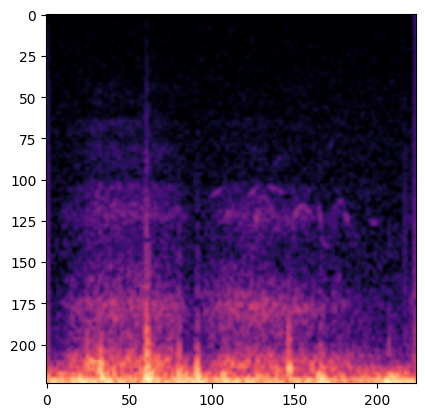

In [6]:
plt.imshow(X_train[5]);

## Transfer Learning

In [ ]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)

base_model.trainable = False # freezeo el modelo base

inputs = keras.Input(shape=(224, 224, 3))
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED) # augmentacion
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1) # normalizacion

x = flip_layer(inputs) # augmentacion
x = scale_layer(x) # normalizacion
x = base_model(x, training=False) # inferencia
x = keras.layers.GlobalAveragePooling2D()(x) # o max pooling
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 175s 14us/step


In [ ]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ MobileNetV3Large            │ (None, 7, 7, 960)     │  2,996,352 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 960)           │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 128)           │    123,008 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 128)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 1)             │        129 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 3,119,489 (11.90 MB)

 Trainable params: 123,137 (481.00 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [9]:
# lr_schedule = keras.optimizers.schedules.PolynomialDecay(
#     initial_learning_rate=1e-3,
#     decay_steps=1000,
#     end_learning_rate=1e-7,
#     power=1.0)

model.compile(
    optimizer=keras.optimizers.Adam(),#learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 100s 717ms/step - auc: 0.5078 - loss: 0.7029 - recall: 0.4291 - val_auc: 0.5683 - val_loss: 0.7085 - val_recall: 0.9960
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 119s 535ms/step - auc: 0.5293 - loss: 0.6927 - recall: 0.4503 - val_auc: 0.5583 - val_loss: 0.6895 - val_recall: 0.8399
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 77s 593ms/step - auc: 0.5415 - loss: 0.6907 - recall: 0.4993 - val_auc: 0.5627 - val_loss: 0.6984 - val_recall: 0.0000e+00
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 83s 604ms/step - auc: 0.5445 - loss: 0.6902 - recall: 0.4123 - val_auc: 0.5567 - val_loss: 0.6880 - val_recall: 0.4387
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 79s 610ms/step - auc: 0.5411 - loss: 0.6906 - recall: 0.5037 - val_auc: 0.5568 - val_loss: 0.6893 - val_recall: 0.0000e+00
Epoch 6/50
 47/130 ━━━━━━━━━━━━━━━━━━━━ 42s 507ms/step - auc: 0.5188 - loss: 0.6947 - recall: 0.1903

KeyboardInterrupt: 

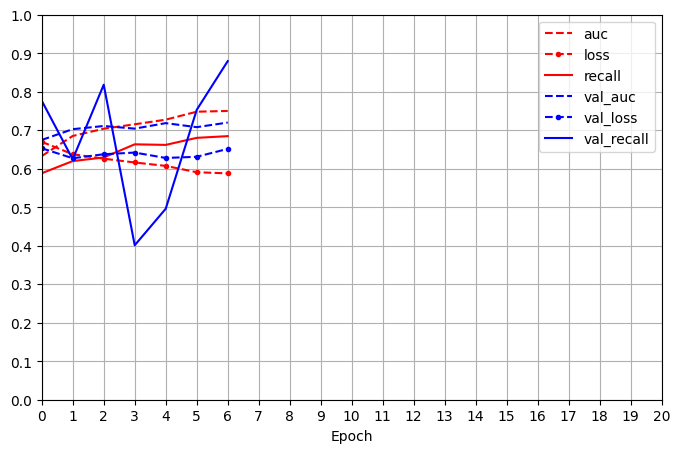

In [12]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 20], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "r-", "b--","b--.", "b-"], xticks=range(0, 21), yticks=np.arange(0, 1.1, 0.1))
plt.show()

In [13]:
model.evaluate(X_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 25s 605ms/step - auc: 0.6646 - loss: 0.6494 - recall: 0.5719


[0.6493515968322754, 0.6645519137382507, 0.5718799233436584]

In [15]:
model.save(f'./mobile_net/modelos/{dataset}.keras')

## Fine-Tunning

In [ ]:
# Descongelar solo las últimas capas (desde el bloque 13)
mobile_net.trainable = True

set_trainable = False
for layer in mobile_net.layers:
    if layer.name == "block_13_expand":  # desde acá para abajo, entrenable
        set_trainable = True
    layer.trainable = set_trainable

In [18]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 3,291,333 (12.56 MB)

 Trainable params: 2,568,321 (9.80 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 688,900 (2.63 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-6),  # Low learning rate
    loss=keras.losses.Hinge(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()],
)

In [20]:
history_fine_tunning = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[early_stop])

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 414s 3s/step - auc_1: 0.5926 - loss: 0.9284 - recall_1: 0.5630 - val_auc_1: 0.7691 - val_loss: 0.5859 - val_recall_1: 0.8063
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 469s 4s/step - auc_1: 0.6554 - loss: 0.7121 - recall_1: 0.6223 - val_auc_1: 0.7553 - val_loss: 0.6132 - val_recall_1: 0.8636
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 465s 4s/step - auc_1: 0.7163 - loss: 0.6261 - recall_1: 0.6673 - val_auc_1: 0.7450 - val_loss: 0.6517 - val_recall_1: 0.8953
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 489s 4s/step - auc_1: 0.7380 - loss: 0.6026 - recall_1: 0.6688 - val_auc_1: 0.7346 - val_loss: 0.6727 - val_recall_1: 0.9071
Epoch 5/50
 12/130 ━━━━━━━━━━━━━━━━━━━━ 7:35 4s/step - auc_1: 0.7394 - loss: 0.6069 - recall_1: 0.7003

KeyboardInterrupt: 

In [40]:
model.evaluate(X_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 496ms/step - auc_2: 0.7519 - loss: 0.6082 - recall_2: 0.5671


[0.6081942319869995, 0.7519128322601318, 0.5671405792236328]